In [1]:
print("nama : Rayya Syauqi Alulu'i")
print("NIM : 103012300268")

nama : Rayya Syauqi Alulu'i
NIM : 103012300268



## Implementasi Konvolusi 2D Manual dengan Zero-Padding Berdasarkan teori Spatial Filter
 
Fitur:
  1. convolve2d()   - konvolusi 2D manual dengan zero-padding
  2. smooth_image() - smoothing (low-pass) menggunakan 3×3 averaging filter
  3. sharpen_image()- sharpening (high-pass) menggunakan 3×3 Laplacian kernel


# import yang penting2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as Image

# 1. Fungsi convolusi 2D

In [4]:
def convolve2d(img, kernel):
    """
    Melakukan konvolusi 2D antara citra grayscale dan kernel N x N
    menggunakan zero-padding sehingga ukuran output = ukuran input.
 
    Berdasarkan rumus diskrit dari slide:
        h(x, y) = f(x, y) ⊗ g(x, y)
                = Σ_m Σ_n  f(x+m, y+n) · g(m, n)
 
    di mana g(x,y) adalah convolution mask / kernel yang bergeser
    pada setiap titik citra f(x,y), dan jumlah perkalian pada setiap
    titik merupakan hasil konvolusi h(x,y).
 
    Parameters
    ----------
    img    : np.ndarray  shape (H, W)  —  citra grayscale, dtype float
    kernel : np.ndarray  shape (N, N)  —  convolution mask, N harus ganjil
 
    Returns
    -------
    output : np.ndarray  shape (H, W)  —  hasil konvolusi, dtype float
    """
    img = img.astype(np.float64)
    kernel = np.array(kernel, dtype=np.float64)
 
    H, W = img.shape
    N = kernel.shape[0]
 
    # N harus ganjil agar titik target berada tepat di tengah kernel
    # (sesuai slide: "N selalu kelipatan ganjil")
    assert N % 2 == 1, "Ukuran kernel harus ganjil (1, 3, 5, ...)"
    assert kernel.shape[0] == kernel.shape[1], "Kernel harus persegi N x N"
 
    pad = N // 2   # jumlah padding di setiap sisi
 
    # ── Zero-padding ──────────────────────────────────────────────────────────
    # Tambahkan baris/kolom nol di sekeliling citra
    # sehingga piksel di tepi tetap bisa diproses.
    padded = np.zeros((H + 2 * pad, W + 2 * pad), dtype=np.float64)
    padded[pad:pad + H, pad:pad + W] = img   # salin citra asli ke tengah
 
    # ── Konvolusi: geser kernel pada setiap piksel ────────────────────────────
    # Sesuai algoritma dari slide (hal. 17):
    #   ImageResult[i][j] = Σ Image[i+m][j+n] * Mask[m][n]
    output = np.zeros((H, W), dtype=np.float64)
 
    for i in range(H):
        for j in range(W):
            acc = 0.0
            for m in range(N):
                for n in range(N):
                    # piksel tetangga dari citra ter-pad
                    pixel  = padded[i + m][j + n]
                    # elemen kernel yang bersesuaian
                    weight = kernel[m][n]
                    # perkalian dan penjumlahan (sesuai slide hal. 17)
                    acc += pixel * weight
            output[i][j] = acc
 
    return output

# 2. SMOOTHING — LOW-PASS FILTER (Averaging / Box Filter)

In [5]:
def smooth_image(img):
    """
    Menerapkan 3×3 averaging (box) filter pada citra.
 
    Kernel averaging 3×3:
        [ 1/9  1/9  1/9 ]
        [ 1/9  1/9  1/9 ]
        [ 1/9  1/9  1/9 ]
 
    Setiap piksel diganti dengan rata-rata 9 piksel di sekitarnya.
    Efek: menghaluskan citra (mengurangi noise, memblur tepi).
    Sesuai slide "Smoothing Filters: Averaging" — mask size 3×3.
 
    Parameters
    ----------
    img : np.ndarray  shape (H, W)  —  citra grayscale uint8 atau float
 
    Returns
    -------
    result : np.ndarray  shape (H, W)  —  citra setelah smoothing, uint8
    """
    # Definisi kernel averaging 3×3
    averaging_kernel = np.array([
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9]
    ], dtype=np.float64)
 
    # Jalankan konvolusi
    result = convolve2d(img.astype(np.float64), averaging_kernel)
 
    # Normalisasi: clamp ke [0, 255] dan konversi ke uint8
    result = np.clip(np.round(result), 0, 255).astype(np.uint8)
    return result

## 3. SHARPENING — HIGH-PASS FILTER (Laplacian Kernel)

In [6]:
def sharpen_image(img):
    """
    Menerapkan 3×3 Laplacian kernel untuk sharpening (edge enhancement).
 
    Kernel Laplacian 3×3 (dengan pusat +8, sudut -1):
        [ -1  -1  -1 ]
        [ -1   8  -1 ]
        [ -1  -1  -1 ]
 
    Cara kerja:
      1. Hitung respons Laplacian (mendeteksi tepi / perubahan intensitas tajam)
      2. Tambahkan ke citra asli → citra asli + detail tepi = citra lebih tajam
 
    Formula: sharpened = original + Laplacian(original)
 
    Parameters
    ----------
    img : np.ndarray  shape (H, W)  —  citra grayscale uint8 atau float
 
    Returns
    -------
    result : np.ndarray  shape (H, W)  —  citra setelah sharpening, uint8
    """
    # Definisi kernel Laplacian 3×3
    laplacian_kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float64)
 
    img_float = img.astype(np.float64)
 
    # Hitung respons Laplacian
    laplacian_response = convolve2d(img_float, laplacian_kernel)
 
    # Tambahkan ke citra asli untuk memperkuat tepi
    sharpened = img_float + laplacian_response
 
    # Normalisasi: clamp ke [0, 255] dan konversi ke uint8
    result = np.clip(np.round(sharpened), 0, 255).astype(np.uint8)
    return result

# 4. Manual Verification

In [8]:
def verify_manual(img, kernel, row, col, expected=None):
    """
    Hitung konvolusi secara manual untuk satu piksel (row, col)
    dan bandingkan dengan hasil convolve2d().
    Berguna untuk verifikasi seperti contoh di slide hal. 14.
    """
    img = np.array(img, dtype=np.float64)
    kernel = np.array(kernel, dtype=np.float64)
    N = kernel.shape[0]
    pad = N // 2
 
    H, W = img.shape
    padded = np.zeros((H + 2*pad, W + 2*pad))
    padded[pad:pad+H, pad:pad+W] = img
 
    acc = 0.0
    print(f"\nVerifikasi manual piksel ({row}, {col}):")
    print(f"{'Piksel':>12}  {'Kernel':>8}  {'Produk':>10}")
    print("-" * 36)
    for m in range(N):
        for n in range(N):
            p = padded[row + m][col + n]
            k = kernel[m][n]
            print(f"  f[{row+m-pad},{col+n-pad}]={p:4.0f}  g[{m},{n}]={k:5.2f}  {p*k:10.4f}")
            acc += p * k
    print(f"{'':>12}  {'Σ =':>8}  {acc:10.4f}")
 
    if expected is not None:
        status = "✓ SESUAI" if abs(acc - expected) < 1e-6 else "✗ TIDAK SESUAI"
        print(f"  Expected: {expected}  →  {status}")
    return acc

# Test Code


Text(0.5, 1.0, 'Citra Grayscale Asli')

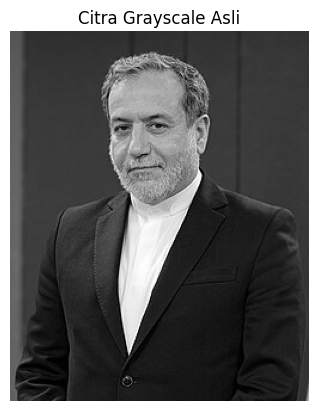

In [16]:
aragachi_white_black = Image.open("aragachi.jpg").convert("L") 
aragachi_white_black_array = np.array(aragachi_white_black)

# Tampilkan citra asli
plt.imshow(aragachi_white_black_array, cmap='gray')
plt.axis('off')
plt.title("Citra Grayscale Asli")


(np.float64(-0.5), np.float64(249.5), np.float64(309.5), np.float64(-0.5))

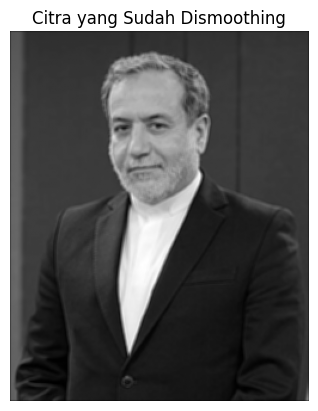

In [17]:
# smooting
aragachi_smoothed = smooth_image(aragachi_white_black_array)
plt.figure()
plt.imshow(aragachi_smoothed, cmap='gray')
plt.title("Citra yang Sudah Dismoothing")
plt.axis('off')

(np.float64(-0.5), np.float64(249.5), np.float64(309.5), np.float64(-0.5))

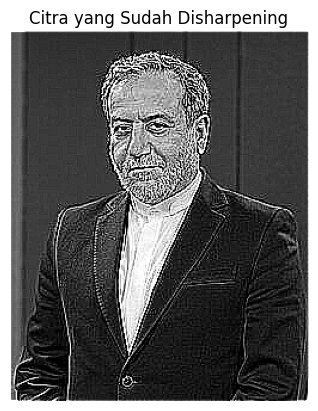

In [18]:
# sharpening
aragachi_sharpened = sharpen_image(aragachi_white_black_array)
plt.figure()
plt.imshow(aragachi_sharpened, cmap='gray')
plt.title("Citra yang Sudah Disharpening")
plt.axis('off')

In [ ]:
# manual verification
example_kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float64)

verify_manual(aragachi_white_black_array, example_kernel, row=2, col=2)



Verifikasi manual piksel (2, 2):
      Piksel    Kernel      Produk
------------------------------------
  f[1,1]=  84  g[0,0]= 0.11      9.3333
  f[1,2]=  83  g[0,1]= 0.11      9.2222
  f[1,3]=  84  g[0,2]= 0.11      9.3333
  f[2,1]=  84  g[1,0]= 0.11      9.3333
  f[2,2]=  84  g[1,1]= 0.11      9.3333
  f[2,3]=  84  g[1,2]= 0.11      9.3333
  f[3,1]=  85  g[2,0]= 0.11      9.4444
  f[3,2]=  84  g[2,1]= 0.11      9.3333
  f[3,3]=  84  g[2,2]= 0.11      9.3333
                   Σ =     84.0000


np.float64(83.99999999999997)